# Imports, Vars and Functions

In [1]:
%pip install lightgbm catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # one-liner charts, high-level
import plotly.graph_objects as go # full control chart

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.base import clone

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping
from catboost import CatBoostClassifier, Pool

import optuna

import typing

import warnings

## Vars

In [3]:
TARGET = "Exited"
N_SPLITS = 5

categorical_columns = ["Geography", "Gender"]
numerial_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]

drop_columns  = ["id", "CustomerId", "source", "Surname"]
submission_columns = ["id", "Exited"]

## Functions

### Load Data

In [4]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Bank Churn/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

### Data splitter

In [5]:
def data_spliter(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train = df[df['source'] == 'train'].drop(columns=drop_columns)
    submission_df = df[df['source'] == 'test'].drop(columns=['source', 'Surname', TARGET])

    X_train = train.drop(columns=[TARGET])
    y_train = train[TARGET]

    return X_train, y_train, submission_df

In [90]:
train_df, test_df, df = load_data(option="colab")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA

In [9]:
len(df)

25000

-   **Customer** ID: Уникальный идентификатор каждого клиента.
-   **Surname**: Фамилия клиента.
-   **Credit Score**: Числовое значение, представляющее кредитный рейтинг клиента.
-   **Geography**: Страна проживания клиента (Франция, Испания или Германия).
-   **Gender**: Пол клиента (Мужской или Женский).
-   **Age**: Возраст клиента.
-   **Tenure**: Количество лет, которое клиент обслуживается в банке.
-   **Balance**: Баланс на счёте клиента.
-   **NumOfProducts**: Количество банковских продуктов, которыми пользуется клиент (например, сберегательный счёт, кредитная карта).
-   **HasCrCard**: Наличие кредитной карты у клиента (1 = да, 0 = нет).
-   **IsActiveMember**: Является ли клиент активным членом банка (1 = да, 0 = нет).
-   **EstimatedSalary**: Предполагаемая заработная плата клиента.
-   **Exited**: Ушёл ли клиент (1 = да, 0 = нет).


In [ ]:
df.info()

In [ ]:
df.describe().T

In [ ]:
df.isna().sum()

In [ ]:
df.head()

## Pairplot

In [10]:
fig = sns.pairplot(
    data=train_df[numerial_columns + [TARGET]],
    hue=TARGET,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15, "edgecolor": None},
    diag_kws={"fill": True, "alpha": 0.6},
    palette={0: "#2196F3", 1: "#FF5722"},
    # corner=True,
)
fig.figure.suptitle("Pairplot of Numerical Features by Churn Status", y=1.02, fontsize=16, fontweight="bold")

Text(0.5, 1.02, 'Pairplot of Numerical Features by Churn Status')

Error in callback <function _draw_all_if_interactive at 0x7bf239b6b6a0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7bf239b68ae0> (for post_execute):


KeyboardInterrupt: 

## Correlations

<Axes: >

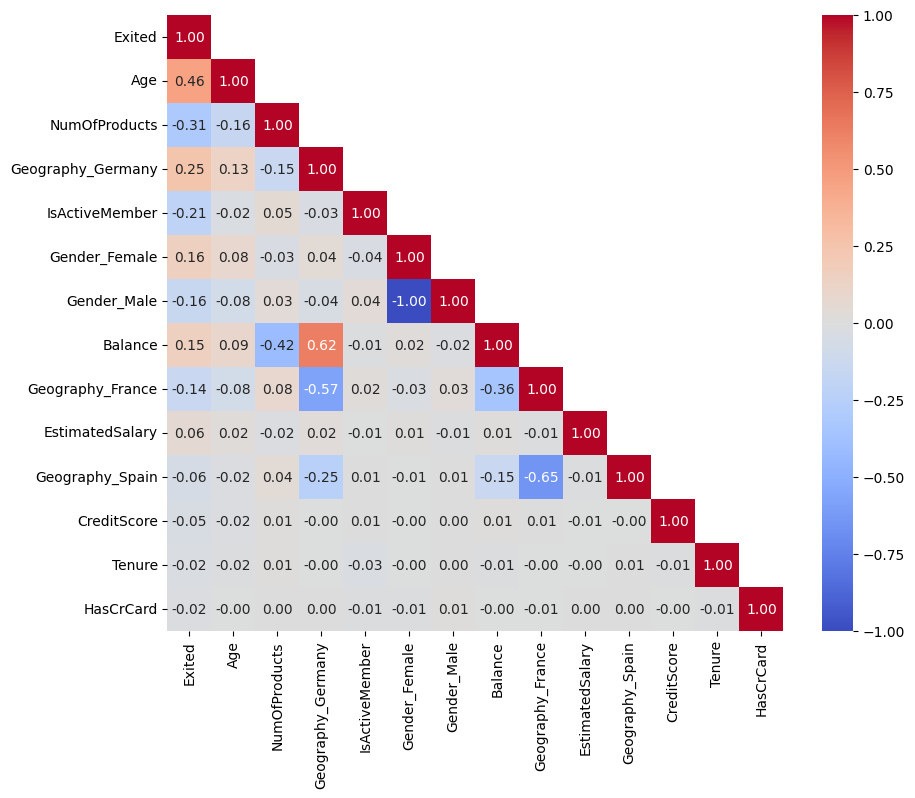

In [19]:
corr_df = pd.get_dummies(
        data=df.drop(columns=drop_columns + ["source"] + ["Surname"]),
        columns=["Gender", "Geography"],
    ).corr()
sorted_columns = corr_df[TARGET].abs().sort_values(ascending=False).index.tolist()
corr_df = corr_df.loc[sorted_columns, sorted_columns]
corr_mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

plt.figure(figsize=(10,8))
sns.heatmap(
    data=corr_df,
    mask=corr_mask,
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    square=True,
    center=0
)

In [40]:
corr_df[corr_mask] = np.nan
px.imshow(
    corr_df,
    text_auto= ".2f",
    aspect = True,
    color_continuous_scale="RdBu_r"
).update_traces(hoverongaps=False)

## Surnames

In [ ]:
display(df['Surname'].value_counts().reset_index())

In [ ]:
df[df['Surname'].str.endswith('ov') | df['Surname'].str.endswith('ova') | df['Surname'].str.endswith('ev') | df['Surname'].str.endswith('eva')]

In [ ]:
df[df['Surname'].str.contains("?", regex=False)]

In [ ]:
display(df[df['Surname'].str.contains("'", regex=False)])

## Balance

<Axes: xlabel='Balance', ylabel='Count'>

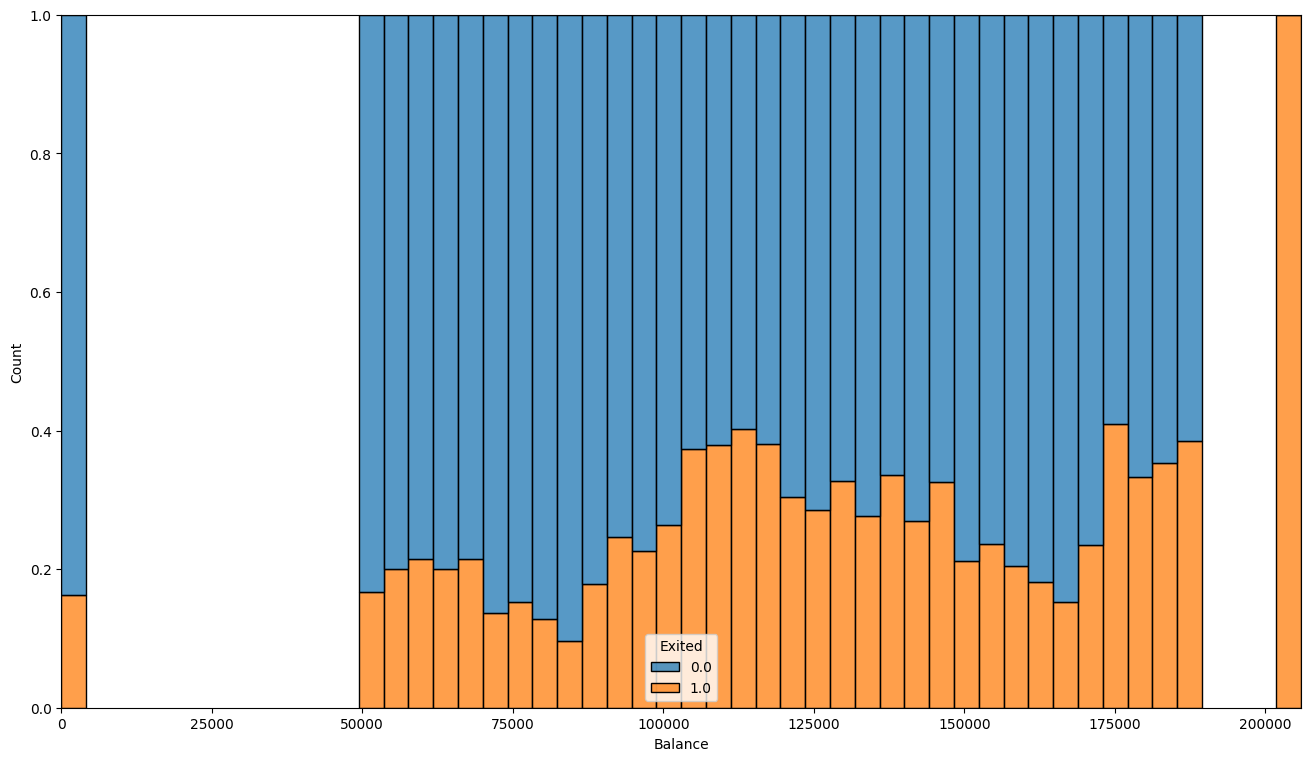

In [12]:
plt.figure(figsize=(16,9))
sns.histplot(
    data=train_df,
    x="Balance",
    hue='Exited',
    bins=50,
    multiple='fill',
)

In [13]:
df['Balance'].drop_duplicates().sort_values(ascending=False).head()

,Balance
5754,205962.00
4965,203715.15
12478,187841.99
16912,187534.79
4517,187530.66


In [14]:
df[df['Balance'] > 200000]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source
4965,4965,15798964.0,O'Donnell,613.0,Spain,Male,51.0,8.0,203715.15,1.0,1.0,1.0,157549.90,1.0,train
5754,5754,15673074.0,Chidiebele,726.0,France,Female,52.0,9.0,205962.00,1.0,1.0,0.0,75888.65,1.0,train


## Salary

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="EstimatedSalary",
    hue='Exited',
    bins=50,
    multiple='fill',
)

## Age

In [15]:
px.histogram(
    data_frame=df,
    x = 'Age',
    # y='Balance',
    color='Exited',
    barmode='overlay',
    opacity=0.6,
    marginal="box",
    # histfunc="avg"
    # nbins=70,
    # text_auto=True
    # range_x=[17,74]
).update_layout(bargap=0.1)

In [16]:
df['Age'].value_counts().reset_index().sort_values(by='Age').head()

,Age,count
52,18.0,7
48,19.0,15
44,20.0,37
41,21.0,66
36,22.0,111


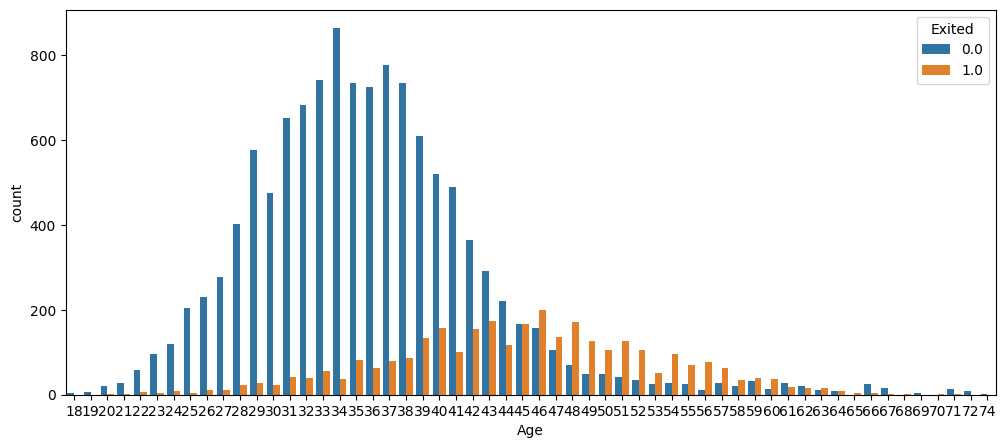

In [17]:
plt.figure(figsize=(12,5))
ax = sns.countplot(
    data=train_df,
    x=df['Age'].astype(int),
    hue='Exited',
)

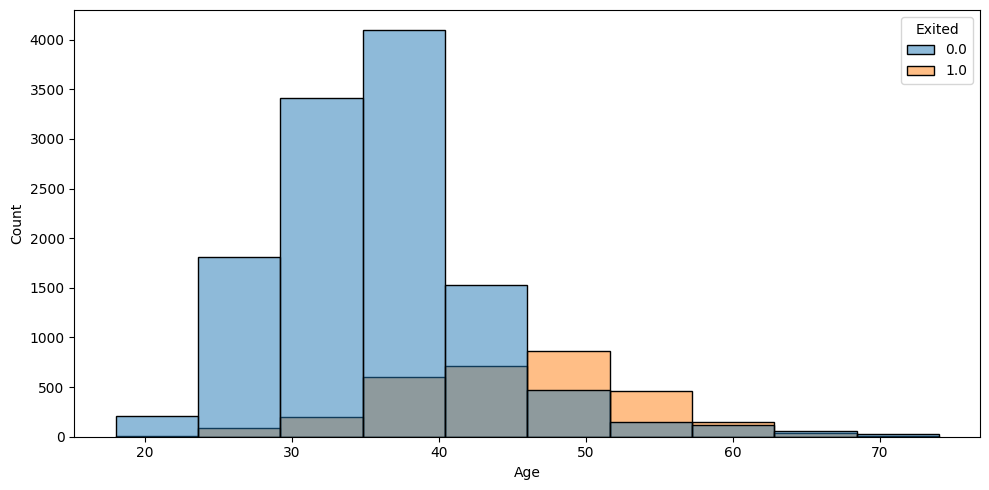

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="Age",
    hue='Exited',
    bins=10,
    # multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

## Credit Score

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=train_df,
    x="CreditScore",
    hue='Exited',
    bins=5,
    multiple='fill',
)
# plt.xticks(np.arange(18,75))
plt.tight_layout()

## Geography

In [239]:
px.histogram(
    df,
    x='Geography',
    color = 'Exited',
    barmode='overlay',
    opacity=0.6,
)

## Num Products

In [240]:
px.histogram(
    df,
    x='NumOfProducts',
    color = 'Exited',
    barmode='overlay',
    opacity=0.6,
)

# Feature Engineering

In [54]:
train_df, test_df, df = load_data(option='colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# TODO
# NumOfProducts is not ordinal, add is_3_or_4_products or set as catgory
# Age × IsActiveMember is a sensible interaction: inactive older customers are the highest-risk group.
def feature_engineering(df):
  original_columns = df.columns.tolist()
  print("Engineering features...")

  # 1. Interaction & Ratio Features
  df['Balance_to_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
  df['Age_to_Tenure_Ratio'] = df['Tenure'] / (df['Age'] + 1)
  df['Products_per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

  df['Age_Activity_Combo'] = df['Age'] * df['IsActiveMember']

  # 2. Financial Status & Behavior Indicators
  df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)


  # 3. Engagement Score
  df['Customer_Activity_Index'] = df['HasCrCard'] + df['IsActiveMember'] + (df['NumOfProducts'] > 1).astype(int)

  # 4. Surname & Demographic Patterns
  # Surname special character rules
  df['Surname_Has_Question'] = df['Surname'].str.contains('?', regex=False).astype(int)

  # Endings often representing specific ethnicities/families in synthetic datasets
  df['Surname_Ends_With_Slavic'] = df['Surname'].str.endswith(('ov', 'ova', 'ev', 'eva')).astype(int)

  df['Surname_Contains_Apostrophe'] = df['Surname'].str.contains("'", regex=False).astype(int)

  # Surname legnth
  df['Surname_Length'] = df['Surname'].str.len()

  # Surname first and last characters
  df['Surname_Start'] = df['Surname'].str[0].str.lower().astype('category')
  df['Surname_End'] = df['Surname'].str[-1].str.lower().astype('category')

  # Convert gended to numbers
  df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

  # Make Geography categorical column:
  df['Geography'] = df['Geography'].astype("category")

  # Num of products 3 or 4
  df['Is_products_3_or_4'] = (df['NumOfProducts'] > 2).astype(int)


  engineered_features = [k for k in df.columns.tolist() if k not in original_columns]

  print(f"\nAdded {len(engineered_features)} features")
  print(f"Features added:")
  for idx, f in enumerate(engineered_features):
    print(f"{idx + 1}: {f}")
  return df

In [55]:
df = feature_engineering(df)

Engineering features...

Added 13 features
Features added:
1: Balance_to_Salary_Ratio
2: Age_to_Tenure_Ratio
3: Products_per_Tenure
4: Age_Activity_Combo
5: Is_Zero_Balance
6: Customer_Activity_Index
7: Surname_Has_Question
8: Surname_Ends_With_Slavic
9: Surname_Contains_Apostrophe
10: Surname_Length
11: Surname_Start
12: Surname_End
13: Is_products_3_or_4


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   id                           25000 non-null  int64   
 1   CustomerId                   25000 non-null  float64 
 2   Surname                      25000 non-null  object  
 3   CreditScore                  25000 non-null  float64 
 4   Geography                    25000 non-null  category
 5   Gender                       25000 non-null  int64   
 6   Age                          25000 non-null  float64 
 7   Tenure                       25000 non-null  float64 
 8   Balance                      25000 non-null  float64 
 9   NumOfProducts                25000 non-null  float64 
 10  HasCrCard                    25000 non-null  float64 
 11  IsActiveMember               25000 non-null  float64 
 12  EstimatedSalary              25000 non-null  float64 
 13  E

In [125]:
with pd.option_context('display.max_columns', None):
    display(df.head())

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,source,Balance_to_Salary_Ratio,Age_to_Tenure_Ratio,Products_per_Tenure,Is_Zero_Balance,Customer_Activity_Index,Surname_Has_Question,Surname_Ends_With_Slavic
0,0,15653521.0,Nkemakonam,667.0,Germany,1,33.0,3.0,131769.04,1.0,1.0,1.0,162719.69,0.0,train,0.809787,0.088235,0.250000,0,2.0,0,0
1,1,15699005.0,Chiekwugo,614.0,France,0,31.0,2.0,110615.47,1.0,1.0,1.0,181879.56,0.0,train,0.608176,0.062500,0.333333,0,2.0,0,0
2,2,15656912.0,Chiang,683.0,Germany,0,24.0,6.0,115074.02,2.0,1.0,0.0,109688.82,0.0,train,1.049086,0.240000,0.285714,0,2.0,0,0
3,3,15700772.0,Ch'ang,678.0,France,0,38.0,9.0,0.00,1.0,1.0,0.0,122823.84,1.0,train,0.000000,0.230769,0.100000,1,1.0,0,0
4,4,15583850.0,Chiang,588.0,Spain,0,39.0,3.0,0.00,2.0,1.0,1.0,136910.18,0.0,train,0.000000,0.075000,0.500000,1,3.0,0,0


# Modelling

In [10]:
X, y, submission_df = data_spliter(df)

In [11]:
cv = StratifiedKFold(
    n_splits = N_SPLITS,
    shuffle = True,
    random_state=42
)

## LightGBM

In [181]:
# lgb_params = {
#     "n_estimators":10000,
#     "learning_rate": 0.03,
#     "num_leaves": 27,
#     "min_child_samples": 30,
#     "colsample_bytree": 0.6,
#     "subsample": 0.8,
#     "subsample_freq": 1
# }

In [152]:
# preprocess = ColumnTransformer(
#     [("cat", OneHotEncoder(handle_unknown="ignore"), ['Geography'])],
#     remainder="passthrough"
# )

In [ ]:
X, y, submission_df = data_spliter(df)

In [65]:
def objective_lgb(trial):
    params = {
        "n_estimators": 3000,          # fixed; early stopping decides the real count
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 255),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    oof_local = np.zeros(len(X))
    iters = []

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
            X_train, y_train = X.iloc[tr_idx], y.iloc[tr_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]


            model = LGBMClassifier(**params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                categorical_feature=['Geography','Surname_Start','Surname_End'],
                eval_metric="auc",
                callbacks=[early_stopping(100, verbose=False)],
            )

            oof_local[val_idx] = model.predict_proba(X_val)[:, 1]
            iters.append(model.best_iteration_)

            # let Optuna kill hopeless trials early
            trial.report(roc_auc_score(y_val, oof_local[val_idx]), fold)
            if trial.should_prune():
                raise optuna.TrialPruned()


    trial.set_user_attr("best_iters", iters)
    return roc_auc_score(y, oof_local)

In [ ]:
# Re-split X and y to include the newly engineered features
# X, y, submission_df = data_spliter(df)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print(study.best_value)
print(study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
oof = np.zeros(len(X))
submission_results = np.zeros(len(submission_df))
fold_train_results, fold_validation_results = [], []
best_iters = []

In [17]:
# lgb_params_optuna_1 = {'n_estimators': 10000, 'learning_rate': 0.02757359293934948, 'num_leaves': 244, 'max_depth': 10, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'subsample_freq': 1, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}

# lgb_params_optuna_2 = {'n_estimators': 10000,'learning_rate': 0.014588395647499933, 'num_leaves': 106, 'max_depth': 4, 'min_child_samples': 113, 'subsample': 0.7534735323110857, 'subsample_freq': 4, 'colsample_bytree': 0.5332132855147186, 'reg_alpha': 4.304692668736199e-07, 'reg_lambda': 2.4512199118681435e-05}

lgb_params_optuna_3 = {'n_estimators': 10000, 'learning_rate': 0.032442034205477026, 'num_leaves': 91, 'max_depth': 4, 'min_child_samples': 61, 'subsample': 0.7251686814955571, 'subsample_freq': 3, 'colsample_bytree': 0.6761636926528118, 'reg_alpha': 0.49537613035821393, 'reg_lambda': 0.06011464654656114}

In [21]:
for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_train, y_train = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]


    model = LGBMClassifier(**lgb_params_optuna_3)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=['Geography'],
        eval_metric="auc",
        callbacks=[early_stopping(100, verbose=False)],
    )

    oof_pred = model.predict_proba(X_val)[:, 1]
    train_pred = model.predict_proba(X_train)[:, 1]

    oof_auc = roc_auc_score(y_val, oof_pred)
    train_auc = roc_auc_score(y_train, train_pred)

    oof[val_idx] = oof_pred
    fold_train_results.append(train_auc)
    fold_validation_results.append(oof_auc)
    best_iters.append(model.best_iteration_)

    submission_results += model.predict_proba(X_sub_raw)[:, 1] / N_SPLITS

    print(f"======= FOLD: {fold} =======")
    print(f"TRAIN AUC: {train_auc:.5f} | VAL AUC: {oof_auc:.5f} | "
          f"DELTA: {oof_auc - train_auc:+.5f} | BEST ITER: {model.best_iteration_}")

tr, va = np.array(fold_train_results), np.array(fold_validation_results)
print("\n====== CROSS VALIDATION ENDED ======")
print(f"TRAIN AVG AUC: {tr.mean():.5f} +/- {tr.std():.5f} | "
      f"VAL AVG AUC: {va.mean():.5f} +/- {va.std():.5f}")
print(f"MEAN BEST ITER: {np.mean(best_iters):.0f}")
print(f"\nOOF AUC: {roc_auc_score(y, oof):.5f}")

======= FOLD: 0 =======
TRAIN AUC: 0.94428 | VAL AUC: 0.92272 | DELTA: -0.02155 | BEST ITER: 239
======= FOLD: 1 =======
TRAIN AUC: 0.94484 | VAL AUC: 0.93316 | DELTA: -0.01168 | BEST ITER: 311
======= FOLD: 2 =======
TRAIN AUC: 0.93768 | VAL AUC: 0.93276 | DELTA: -0.00492 | BEST ITER: 148
======= FOLD: 3 =======
TRAIN AUC: 0.94021 | VAL AUC: 0.93517 | DELTA: -0.00503 | BEST ITER: 208
======= FOLD: 4 =======
TRAIN AUC: 0.94862 | VAL AUC: 0.92866 | DELTA: -0.01996 | BEST ITER: 383

====== CROSS VALIDATION ENDED ======
TRAIN AVG AUC: 0.94332 +/- 0.00351 | VAL AVG AUC: 0.92920 +/- 0.00497
MEAN BEST ITER: 255

OOF AUC: 0.93002


In [ ]:
# for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
#   with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     X_train, y_train = X.iloc[tr_idx], y.iloc[tr_idx]
#     X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

#     # fit preprocessor on train only, apply to val and test
#     pre = clone(preprocess)
#     X_train_t = pre.fit_transform(X_train, y_train)
#     X_val_t = pre.transform(X_val)
#     X_sub_t = pre.transform(X_sub_raw)

#     model = LGBMClassifier(**lgb_params_optuna_2)
#     model.fit(
#         X_train_t, y_train,
#         eval_set=[(X_val_t, y_val)],
#         eval_metric="auc",
#         callbacks=[early_stopping(100, verbose=False)],
#     )

#     oof_pred = model.predict_proba(X_val_t)[:, 1]
#     train_pred = model.predict_proba(X_train_t)[:, 1]

#     oof_auc = roc_auc_score(y_val, oof_pred)
#     train_auc = roc_auc_score(y_train, train_pred)

#     oof[val_idx] = oof_pred
#     fold_train_results.append(train_auc)
#     fold_validation_results.append(oof_auc)
#     best_iters.append(model.best_iteration_)

#     submission_results += model.predict_proba(X_sub_t)[:, 1] / N_SPLITS

#     print(f"======= FOLD: {fold} =======")
#     print(f"TRAIN AUC: {train_auc:.5f} | VAL AUC: {oof_auc:.5f} | "
#           f"DELTA: {oof_auc - train_auc:+.5f} | BEST ITER: {model.best_iteration_}")

# tr, va = np.array(fold_train_results), np.array(fold_validation_results)
# print("\n====== CROSS VALIDATION ENDED ======")
# print(f"TRAIN AVG AUC: {tr.mean():.5f} +/- {tr.std():.5f} | "
#       f"VAL AVG AUC: {va.mean():.5f} +/- {va.std():.5f}")
# print(f"MEAN BEST ITER: {np.mean(best_iters):.0f}")
# print(f"\nOOF AUC: {roc_auc_score(y, oof):.5f}")

In [23]:
imp = pd.DataFrame({
    "feature": model.feature_name_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

imp

,feature,importance
3,Age,682
0,CreditScore,576
9,EstimatedSalary,507
5,Balance,490
11,Age_to_Tenure_Ratio,390
6,NumOfProducts,349
10,Balance_to_Salary_Ratio,332
1,Geography,227
12,Products_per_Tenure,202
8,IsActiveMember,185


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

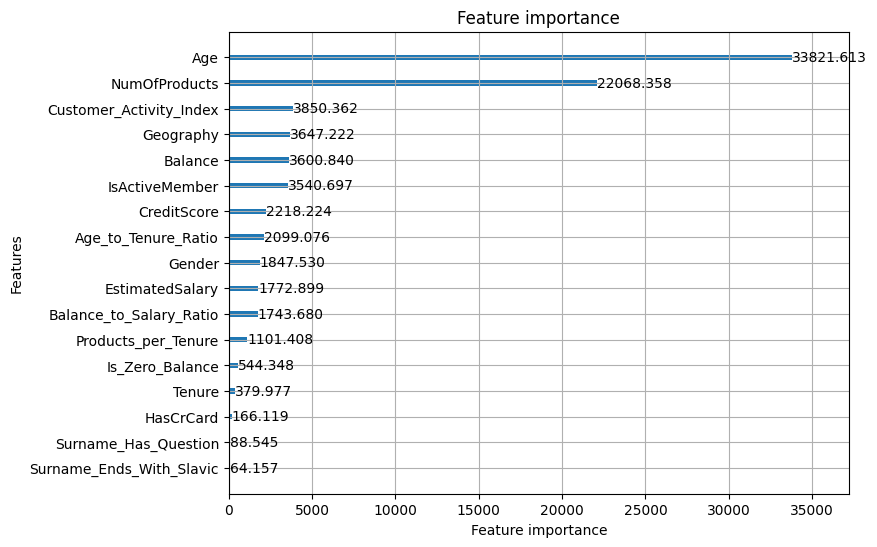

In [22]:
import lightgbm as lgb
lgb.plot_importance(model, importance_type="gain", max_num_features=20, figsize=(8, 6))

In [24]:
submission_df[TARGET] = submission_results

In [25]:
lgb_prediction = submission_df[['id', TARGET]]

In [ ]:
# lgb_params = {
#     "n_estimators":10000,
#     "learning_rate": 0.03,
#     "num_leaves": 24,
#     "min_child_samples": 30,
#     "colsample_bytree": 0.6,
#     "subsample": 0.7,
#     "subsample_freq": 1
# }

In [26]:
lgb_prediction.to_csv('lgb_prediction_v4.csv', index=False)